In [2]:
pip install graphviz

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_graphviz
from graphviz import Source
import numpy as np

In [5]:
iris = load_iris(as_frame=True)
X_iris = iris.data[['petal length (cm)', 'petal width (cm)']].values
y_iris = iris.target

In [6]:
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [7]:
export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=["petal length (cm)", "petal width (cm)"],
    class_names=iris.target_names,
    rounded=True,
    filled=True
    )

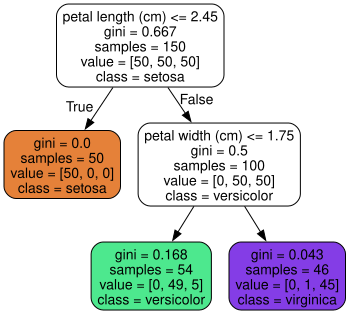

In [8]:
Source.from_file('iris_tree.dot')

In [9]:
from sklearn.datasets import make_moons
X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)
tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

In [19]:
np.random.seed(42)
X_quad = np.random.rand(200, 1) - 0.5 # a single random input feature
y_quad = X_quad ** 2 + 0.025 * np.random.randn(200, 1)
tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=2, random_state=42)

# Exercises
1. What is the approximate depth of a decision tree trained (without restrictions) on a training set with one million instances?
   - Answer: 20 since 1000000//2^n -> n approximately 10.
2. Is a node’s Gini impurity generally lower or higher than its parent’s? Is it generally lower/higher, or always lower/higher?
   - Answer: It is generally lower but not always lower.
3. If a decision tree is overfitting the training set, is it a good idea to try decreasing max_depth?
   - Answer: Yes, it is a good idea to try decreasing the max depth.
4. If a decision tree is underfitting the training set, is it a good idea to try scaling the input features?
   - Answer: No. Scaling the input features generally does not affect decision trees. If a decision tree is underfitting, it is better to reduce regularization, such as increasing `max_depth` or decreasing `min_samples_leaf` or `min_samples_split`.
5. If it takes one hour to train a decision tree on a training set containing one million instances, roughly how much time will it take to train another decision tree on a training set containing ten million instances? Hint: consider the CART algorithm’s computational complexity.
   - Answer:  About 11.6/12 Hours
6. If it takes one hour to train a decision tree on a given training set, roughly how much time will it take if you double the number of features?
    - Answer: 2 hours
7. 

7. Train and fine-tune a decision tree for the moons dataset by following these steps:
    a. Use make_moons(n_samples=10000, noise=0.4) to generate a moons dataset.
    b. Use train_test_split() to split the dataset into a training set and a test set.
    c. Use grid search with cross-validation (with the help of the GridSearchCV class) to find good hyperparameter values for a DecisionTreeClassifier. Hint: try various values for max_leaf_nodes.
    d. Train it on the full training set using these hyperparameters, and measure your model’s performance on the test set. You should get roughly 85% to 87% accuracy.

In [37]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

X_moons, y_moons = make_moons(n_samples=10000, noise=0.4)
X_train, X_test, y_train, y_test = train_test_split(X_moons, y_moons, test_size=0.2, random_state=42)
param_grid = {
    "max_leaf_nodes": list(range(2, 100)),
    "min_samples_split": [2, 3, 4],
}

In [35]:
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy",
)

grid_search.fit(X_train, y_train)


GridSearchCV(cv=3, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_leaf_nodes': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                            13, 14, 15, 16, 17, 18, 19, 20, 21,
                                            22, 23, 24, 25, 26, 27, 28, 29, 30,
                                            31, ...],
                         'min_samples_split': [2, 3, 4]},
             scoring='accuracy')

In [36]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_leaf_nodes': 27, 'min_samples_split': 2}
0.8558741203861144


In [38]:
best_tree = grid_search.best_estimator_
y_pred = best_tree.predict(X_test)
accuracy_score(y_test, y_pred)

0.8635

A `DecisionTreeClassifier` was fine-tuned using `GridSearchCV`. The hyperparameters tested were:

- `max_leaf_nodes`: values from 2 to 99
- `min_samples_split`: 2, 3, and 4

The best hyperparameters found by grid search were:

```python
{'max_leaf_nodes': 27, 'min_samples_split': 2}


## Exercise 8: Grow a Forest

- **a.** Generate 1,000 random subsets of the training set, each containing 100 randomly selected instances.
- **b.** Train one decision tree on each subset using the best hyperparameters from Exercise 7, then evaluate all trees on the test set.
- **c.** For each test instance, collect the predictions from all 1,000 trees and use the most frequent prediction as the final prediction.
- **d.** Evaluate the majority-vote predictions on the test set and compare the accuracy with the first decision tree model.


In [39]:
from sklearn.model_selection import ShuffleSplit

In [55]:
from sklearn.base import clone
rs = ShuffleSplit(n_splits=1000, train_size=100, random_state=42)

forest = []
scores = []

tree_clf = DecisionTreeClassifier(
    max_leaf_nodes=17,   # replace with your best value
    random_state=42
)

for train_index, test_index in rs.split(X_train):
    X_mini_train = X_train[train_index]
    y_mini_train = y_train[train_index]
    
    tree_clone = clone(tree_clf)
    tree_clone.fit(X_mini_train, y_mini_train)

    y_pred = tree_clone.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))
    forest.append(tree_clone)

In [64]:
from scipy.stats import mode
y_preds = np.array([tree.predict(X_test) for tree in forest])
y_pred_majority_votes = mode(y_preds, axis=0).mode.squeeze()

In [65]:
y_pred_majority_votes

array([0, 1, 0, ..., 0, 1, 1])

In [67]:
mode_score = accuracy_score(y_test, y_pred_majority_votes)
mode_score

0.868

The majority-vote model achieved an accuracy of 0.868, or 86.8%, on the test set.

This was done by combining the predictions of 1,000 decision trees and choosing the most frequent prediction for each test instance. The result shows how majority voting can reduce the high variance of individual Decision Trees, similar to the idea behind a Random Forest.